# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: 202520857
* Name: Tung MaiTrung
* Colab account: maitrungtung2602@gmail.com

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



**Report 4A — Live camera classification with MNIST**

In this experiment, I build a convolutional neural network (CNN) classifier using the MNIST handwritten-digit dataset. The trained model classifies grayscale images into ten classes from 0 to 9. I then combine the classifier with the camera-capture function of Google Colab so that a handwritten digit captured by the webcam is preprocessed and classified immediately.

The procedure consists of four steps: training an MNIST classifier, evaluating its accuracy, capturing an image from the webcam, and converting the captured image into the same 28 × 28 format used by MNIST before inference.

**Cell 1 — Train MNIST CNN**

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.20MB/s]


Epoch 1/3 | loss = 0.1719
Epoch 2/3 | loss = 0.0500
Epoch 3/3 | loss = 0.0337


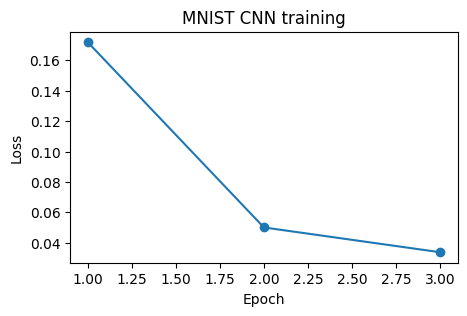

In [1]:
# Report 4A - Build and train an MNIST classifier
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_set = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7,128), nn.ReLU(), nn.Linear(128,10))

    def forward(self, x):
        return self.classifier(self.features(x))

model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs, train_losses = 3, []
for epoch in range(num_epochs):
    model.train(); running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | loss = {avg_loss:.4f}")

plt.figure(figsize=(5,3))
plt.plot(range(1,num_epochs+1), train_losses, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("MNIST CNN training"); plt.show()

**Cell 2 — Test accuracy**

In [2]:
# Evaluate on MNIST test set
model.eval(); correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        pred = model(images).argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy = {accuracy:.2f}%")

Test accuracy = 98.99%


**Cell 3 — Camera**

In [12]:
# Camera capture for Google Colab
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename="mnist_camera.jpg", quality=0.9):
    js = Javascript("""
    async function takePhoto(q) {
      const div=document.createElement('div'), video=document.createElement('video'),
            button=document.createElement('button');
      button.textContent='Capture'; div.appendChild(video); div.appendChild(button);
      document.body.appendChild(div);

      const stream=await navigator.mediaDevices.getUserMedia({video:true});
      video.srcObject=stream; await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);
      await new Promise(resolve => button.onclick=resolve);

      const canvas=document.createElement('canvas');
      canvas.width=video.videoWidth; canvas.height=video.videoHeight;
      canvas.getContext('2d').drawImage(video,0,0);
      stream.getVideoTracks()[0].stop(); div.remove();
      return canvas.toDataURL('image/jpeg',q);
    }
    """)
    display(js)
    data = eval_js(f"takePhoto({quality})")
    with open(filename,"wb") as f:
        f.write(b64decode(data.split(",")[1]))
    return filename

print("Camera ready.")

Camera ready.


Cell 4 — Capture + Recognition

<IPython.core.display.Javascript object>

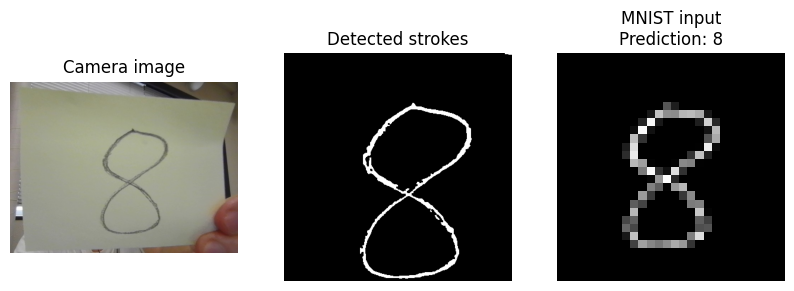

Predicted digit = 8
Confidence = 63.51%


In [17]:
# Report 4A - Capture -> robust preprocessing -> recognition
import cv2

def preprocess_digit(filename):
    original = Image.open(filename).convert("RGB")
    gray = cv2.cvtColor(np.array(original), cv2.COLOR_RGB2GRAY)

    # 1. Use central area of camera image
    h, w = gray.shape
    s = int(min(h, w) * 0.80)
    y0, x0 = (h-s)//2, (w-s)//2
    roi = gray[y0:y0+s, x0:x0+s]

    # 2. Improve contrast and separate dark handwriting from white paper
    roi = cv2.GaussianBlur(roi, (5,5), 0)
    binary = cv2.adaptiveThreshold(
        roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 9
    )

    # 3. Remove small noise and connect thin pencil strokes
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, np.ones((2,2),np.uint8))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 4. Find connected components
    n, labels, stats, centers = cv2.connectedComponentsWithStats(binary, 8)
    cy, cx = binary.shape[0]/2, binary.shape[1]/2
    candidates = []

    for i in range(1, n):
        x, y, bw, bh, area = stats[i]
        if area < 30 or area > 0.20 * binary.size: continue
        if x <= 2 or y <= 2 or x+bw >= binary.shape[1]-2 or y+bh >= binary.shape[0]-2: continue
        dist = np.hypot(centers[i][0]-cx, centers[i][1]-cy)
        score = area / (1 + 0.02*dist)
        candidates.append((score, i))

    if not candidates:
        raise ValueError("Digit not detected. Write it larger/darker and keep it near the center.")

    # 5. Take the most likely digit component
    _, best = max(candidates)
    mask = (labels == best).astype(np.uint8) * 255
    x, y, bw, bh, _ = stats[best]

    pad = max(5, int(0.15 * max(bw, bh)))
    x1, y1 = max(0,x-pad), max(0,y-pad)
    x2, y2 = min(mask.shape[1],x+bw+pad), min(mask.shape[0],y+bh+pad)
    digit = mask[y1:y2, x1:x2]

    # Make thin handwriting slightly thicker
    digit = cv2.dilate(digit, np.ones((2,2),np.uint8), iterations=1)

    # 6. Resize while preserving aspect ratio -> fit inside 20x20
    dh, dw = digit.shape
    scale = 20.0 / max(dw, dh)
    nw, nh = max(1,int(dw*scale)), max(1,int(dh*scale))
    digit = cv2.resize(digit, (nw,nh), interpolation=cv2.INTER_AREA)

    # 7. Center inside MNIST 28x28 canvas
    canvas = np.zeros((28,28), dtype=np.uint8)
    left, top = (28-nw)//2, (28-nh)//2
    canvas[top:top+nh, left:left+nw] = digit

    # Same normalization used for MNIST training
    canvas_img = Image.fromarray(canvas)
    x = transforms.ToTensor()(canvas_img)
    x = transforms.Normalize((0.1307,), (0.3081,))(x).unsqueeze(0)

    return original, Image.fromarray(binary), canvas_img, x


# -------- Capture --------
filename = take_photo()
original, thresholded, processed, x = preprocess_digit(filename)

# -------- Prediction --------
model.eval()
with torch.no_grad():
    prob = torch.softmax(model(x.to(device)), dim=1)
    pred = prob.argmax(dim=1).item()
    confidence = prob[0,pred].item() * 100

# -------- Show processing result --------
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Camera image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(thresholded, cmap="gray")
plt.title("Detected strokes")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(processed, cmap="gray")
plt.title(f"MNIST input\nPrediction: {pred}")
plt.axis("off")

plt.show()

print(f"Predicted digit = {pred}")
print(f"Confidence = {confidence:.2f}%")

**Result**

The trained MNIST classifier was tested using an image captured directly from the webcam. In this example, I wrote the digit 8 on paper, and the preprocessing step successfully extracted the handwritten strokes and converted them into a 28 × 28 MNIST-style image. The CNN correctly recognized the digit as 8 with a confidence of 63.51%, showing that the camera capture and MNIST classifier were successfully integrated.

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


## Tutorial 1 — Deep Learning with PyTorch: A 60 Minute Blitz


**Summary**

I completed the **Deep Learning with PyTorch: A 60 Minute Blitz** tutorial in Google Colab and ran the example code step by step. The tutorial begins with basic tensor operations, then introduces automatic differentiation with `torch.autograd`, neural network construction with `torch.nn`, and finally combines these concepts in a CIFAR-10 image classification example.

By running all of these sections, I could follow the complete PyTorch workflow from data representation and gradient calculation to model construction, training, and evaluation.

**What I learned**

In the **Tensor** section, I ran examples for creating tensors directly from Python data, NumPy arrays, and other tensors. I also tested tensor attributes such as shape, data type, and device. I practiced indexing, slicing, concatenation, element-wise multiplication, matrix multiplication, and in-place operations.

I also moved tensors to the GPU when CUDA was available. This helped me understand that PyTorch tensors are similar to NumPy arrays, but they can also use GPU acceleration. I tested the conversion between NumPy arrays and PyTorch tensors and observed that, in some cases, they share the same underlying memory, so modifying one can also affect the other.

In the **Autograd** section, I ran both forward and backward propagation examples. I used tensors with `requires_grad=True` and called `.backward()` to calculate gradients automatically. For example, I ran the expression:

$Q = 3a^3 - b^2$

and checked the gradients calculated by PyTorch against the expected analytical derivatives. This helped me understand how `autograd` records operations in a computational graph and applies the chain rule automatically during backpropagation.

In the **Neural Networks** section, I created a convolutional neural network by defining a class that inherits from `nn.Module`. I ran the forward pass through convolution, ReLU, max-pooling, flattening, and fully connected layers. I also calculated the loss, called `loss.backward()`, and inspected the gradients stored in the network parameters.

I then used an SGD optimizer and ran the typical training sequence:

`optimizer.zero_grad() -> forward pass -> loss -> loss.backward() -> optimizer.step()`

This made the relationship between forward propagation, gradient calculation, and parameter updating much clearer.

Finally, in the **Training a Classifier** section, I ran the CIFAR-10 example. I loaded and normalized the CIFAR-10 dataset using `torchvision`, created training and test DataLoaders, defined a CNN and loss function, trained the model, and tested its predictions on unseen images. I also ran the code for evaluating classification performance and moving the network and data to the GPU.

After completing the tutorial, I understood how the individual PyTorch components are connected to form a complete deep-learning training pipeline.

**The most difficult part**

The most difficult part for me was understanding the relationship between `loss.backward()` and `optimizer.step()`.

At first, I thought that calling `loss.backward()` directly changed the network weights. After running the examples and inspecting the gradients, I understood that `loss.backward()` only computes and accumulates the gradients in the `.grad` attributes of the parameters. The actual parameter update is performed later by `optimizer.step()`.

I also learned why `optimizer.zero_grad()` is necessary before the next training iteration. PyTorch accumulates gradients by default, so if the previous gradients are not cleared, they will be added to the gradients from the next iteration. Running the code step by step helped me understand this training process more clearly than only reading the explanation.

## Tutorial 2 — Learning PyTorch with Examples

**Summary**

I completed the **Learning PyTorch with Examples** tutorial in Google Colab and ran the examples step by step. The tutorial uses polynomial fitting as a common problem to explain how the same learning process can be implemented at different levels, starting from NumPy and basic PyTorch tensors, then using `autograd`, `torch.nn`, optimizers, custom modules, and dynamic computational graphs.

Running the same type of problem with different implementations helped me see clearly what PyTorch automates compared with a manual numerical implementation.

**What I learned**

In the **Warm-up: NumPy** section, I fitted a third-order polynomial to approximate `sin(x)` using only NumPy. I manually implemented the forward pass, calculated the squared error, derived the gradients of the four polynomial coefficients, and updated the parameters using gradient descent.

In my run, the loss decreased continuously during the 2,000 iterations. For example, it decreased from more than 1,700 at the beginning to about 9.79 at iteration 1999. The final fitted polynomial was approximately:

`y = -0.0218 + 0.8340x + 0.0038x^2 - 0.0901x^3`

This experiment helped me understand what is happening internally during gradient descent because both the gradients and parameter updates were calculated manually.

In the **PyTorch: Tensors** section, I repeated almost the same experiment using PyTorch tensors instead of NumPy arrays. I still calculated the gradients manually, but the data and parameters were represented as PyTorch tensors.

In my execution, the loss decreased to about 8.94 after 2,000 iterations, and the resulting polynomial was approximately:

`y = 0.0013 + 0.8459x - 0.0002x^2 - 0.0918x^3`

The important difference I learned is that PyTorch tensors can be moved to devices such as a GPU, while NumPy arrays normally operate on the CPU.

In the **Tensors and autograd** section, I no longer calculated the gradients manually. I set `requires_grad=True` for the learnable parameters and called:

`loss.backward()`

PyTorch then automatically calculated the gradients and stored them in `a.grad`, `b.grad`, `c.grad`, and `d.grad`. After updating the parameters inside `torch.no_grad()`, I manually cleared the gradients before the next iteration.

This was useful because I could compare it directly with the previous examples and see exactly what `autograd` replaces. Instead of explicitly deriving expressions such as `grad_a`, `grad_b`, `grad_c`, and `grad_d`, PyTorch constructs a computational graph and performs the backward differentiation automatically.

I also ran the **custom autograd function** example using `LegendrePolynomial3`. In this example, the forward and backward operations were defined manually by subclassing `torch.autograd.Function`. This showed me that PyTorch allows automatic differentiation while still giving the programmer control to define a custom derivative when necessary.

In the **PyTorch: nn** section, I used `torch.nn.Sequential`, `torch.nn.Linear`, and `torch.nn.MSELoss` instead of manually managing all of the model parameters. The code became shorter and closer to the way a real neural network is normally implemented.

In my run, the loss again decreased throughout training and reached approximately 9.19 at iteration 1999. The resulting polynomial was approximately:

`y = -0.0155 + 0.8444x + 0.0027x^2 - 0.0916x^3`

This showed me that the higher-level `nn` interface gives approximately the same learning result while reducing the amount of manual code.

In the **PyTorch: optim** section, I replaced the manual parameter update with an optimizer. I used `torch.optim.RMSprop` and followed the standard training sequence:

`optimizer.zero_grad() -> forward pass -> loss.backward() -> optimizer.step()`

This made the training loop much simpler. I also understood that different optimization algorithms such as SGD, RMSprop, and Adam can be used without rewriting the gradient calculation.

Next, I ran the **Custom nn Modules** example and defined a model by subclassing `torch.nn.Module`. The polynomial coefficients were defined as `torch.nn.Parameter`, and the computation was implemented inside the `forward()` method. This helped me understand how more complex neural-network architectures are normally created in PyTorch.

Finally, I ran the **Control Flow + Weight Sharing** example. This example used a dynamic model in which the forward pass could contain normal Python control flow and reuse the same parameter for different polynomial orders. It demonstrated one important feature of PyTorch: the computational graph can be created dynamically during each forward pass.

Overall, the tutorial showed me the progression:

`NumPy -> Tensor -> autograd -> nn.Module -> optimizer -> custom/dynamic model`

By running each implementation, I could see which parts of the training algorithm are handled manually and which parts PyTorch can automate.

**The most difficult part**

The most difficult part for me was understanding the difference between manually computing gradients, using `autograd`, and using higher-level components such as `nn.Module` and `torch.optim`.

At first, these implementations looked like different algorithms. After running them, I understood that the basic learning process is actually the same:

`forward pass -> compute loss -> calculate gradients -> update parameters`

The difference is mainly how much of this process is handled automatically by PyTorch.

I also found the custom `autograd.Function` example difficult because both the forward and backward functions have to be defined correctly. However, this example helped me understand that `autograd` is not just a black box: PyTorch allows us to specify our own forward operation and derivative when a standard operation is not sufficient.

The dynamic-network example was also interesting because the computational graph can change between forward passes while PyTorch can still perform backpropagation correctly. Running this example helped me understand why PyTorch's dynamic graph design is useful for models that contain conditional operations or variable computation.

---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


(You can put text cells around here)

## Report 4C — AI Support for Learning Python and PyTorch on Google Colab

**AI Service Name**

**Gemini in Google Colab / Colab AI**

I chose Gemini in Google Colab because it is directly integrated into the Colab environment. It can use the context of the current notebook to help generate, explain, and correct Python code.

**Official Website**

Google Colab:  
https://colab.research.google.com/

Official Colab information:  
https://research.google.com/colaboratory/faq.html

**Major Functions**

Gemini in Colab can support Python and PyTorch learning by:

- generating code from natural-language instructions,
- explaining existing code,
- suggesting fixes for errors,
- completing and modifying code,
- helping with multi-cell notebook workflows,
- providing step-by-step learning support through **Learn Mode**.

For PyTorch, this is useful for understanding training loops, tensor operations, GPU usage, `nn.Module`, loss functions, and optimizers directly inside the notebook.

**Service Start Date and Version History**

Some important milestones are:

- **May 17, 2023:** Google announced AI-powered coding features for Colab, including code completion, natural-language code generation, and an AI coding assistant.  
  https://blog.google/innovation-and-ai/technology/developers-tools/google-colab-ai-coding-features/

- **December 19, 2023:** AI coding assistance became available more broadly to Colab users, including eligible free users.  
  https://blog.google/innovation-and-ai/products/democratizing-access-to-ai-enabled-coding-with-colab/

- **May 20, 2025:** Google introduced the new **AI-first Colab** powered by Gemini, with stronger notebook understanding, multi-cell editing, error correction, and agent-like workflows.  
  https://developers.googleblog.com/fully-reimagined-ai-first-google-colab/

- **April 8, 2026:** Google introduced **Learn Mode**, which focuses on step-by-step programming guidance instead of only giving complete answers.  
  https://blog.google/innovation-and-ai/technology/developers-tools/colab-updates/

**My Comment**

I think AI support in Colab will gradually change from a code assistant into a personal programming tutor and experiment assistant. In the next few years, it may not only generate code, but also recognize what a student does not understand, explain mistakes, suggest experiments, and help compare different PyTorch models.

For this reason, I think programming education will focus less on memorizing syntax and more on understanding algorithms, checking AI-generated code, and judging whether the results are correct.

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


